# Decision Tree — The Library Version

Same model via scikit-learn, verifying the scratch build — plus two things the library gives for free: a tree drawing and feature importances (README §5). And a live demonstration of the tree's defining weakness: **instability** (README §6).

Test accuracy: 95%  <- same ballpark as the scratch build
Feature importances: cap_cm=0.07, spore_density=0.93   (README §5 — usefulness, not causation)


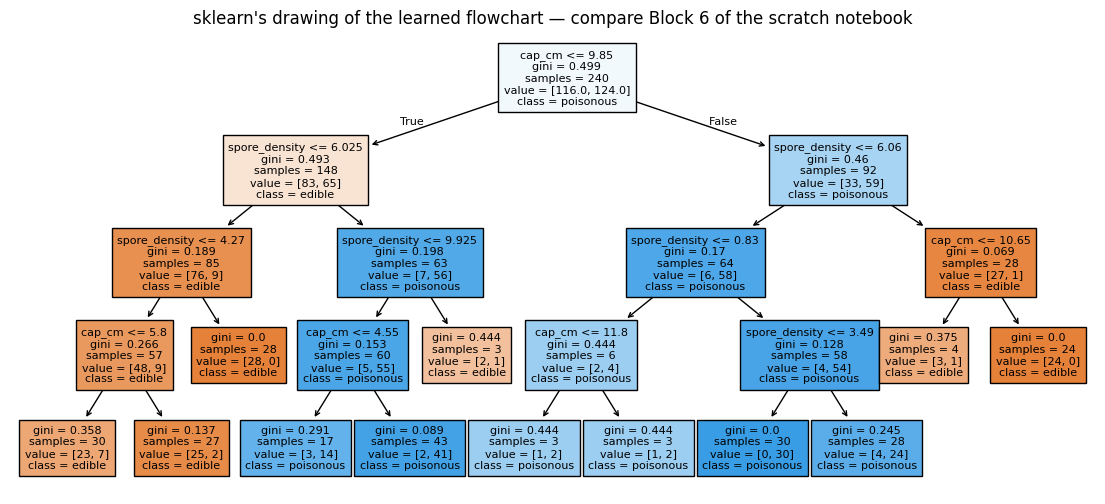

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv("data/mushroom_data.csv")
X = df[["cap_cm", "spore_density"]].values
y = (df.label == "poisonous").astype(int).values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=33)

model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, criterion="gini", random_state=0)
model.fit(Xtr, ytr)                      # our grow() — greedy, recursive, gini
print(f"Test accuracy: {accuracy_score(yte, model.predict(Xte)):.0%}  <- same ballpark as the scratch build")
print(f"Feature importances: cap_cm={model.feature_importances_[0]:.2f}, "
      f"spore_density={model.feature_importances_[1]:.2f}   (README §5 — usefulness, not causation)")

plt.figure(figsize=(14, 6))
plot_tree(model, feature_names=["cap_cm", "spore_density"], class_names=["edible", "poisonous"],
          filled=True, fontsize=8)
plt.title("sklearn's drawing of the learned flowchart — compare Block 6 of the scratch notebook")
plt.show()

In [2]:
# The instability demo (README §6): retrain on 90% subsamples, watch the ROOT question change.
rng = np.random.default_rng(1)
print("Root question across five 90% subsamples of the SAME data:")
for i in range(5):
    keep = rng.choice(len(Xtr), int(0.9 * len(Xtr)), replace=False)
    m = DecisionTreeClassifier(max_depth=4, random_state=0).fit(Xtr[keep], ytr[keep])
    f = m.tree_.feature[0]; t = m.tree_.threshold[0]
    print(f"  run {i+1}: {['cap_cm','spore_density'][f]} <= {t:.2f} ?")
print()
print("Different roots -> entirely different flowcharts below them, from ~the same data.")
print("A single tree is HIGH VARIANCE. Hold that thought — lesson 06 is the cure.")

Root question across five 90% subsamples of the SAME data:
  run 1: cap_cm <= 9.85 ?
  run 2: cap_cm <= 9.85 ?
  run 3: cap_cm <= 9.60 ?
  run 4: cap_cm <= 9.60 ?
  run 5: cap_cm <= 9.85 ?

Different roots -> entirely different flowcharts below them, from ~the same data.
A single tree is HIGH VARIANCE. Hold that thought — lesson 06 is the cure.


**The takeaway:** `DecisionTreeClassifier.fit()` is our `grow()` with decades of engineering (smarter threshold scanning, pruning options). Same greedy gini recursion — you built it. And you've now *seen* the instability that random forests exist to fix.